In [2]:
import pandas as pd

network_data= pd.read_csv("/content/Jacobite_sheets - simple_data.csv")
network_data.head()

,Source,Target,Weight
0,Unknown,Dunfermline,3
1,Robert Gordon,Countess Dunfermline,1
2,Alexander Innes,Dunfermline,1
3,David Burnet,Dunfermline,1
4,G. Gordon,Dunfermline,1


In [3]:
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
G = nx.Graph()
print("Empty graph object 'G' initialized.")

Empty graph object 'G' initialized.


In [5]:
for index, row in network_data.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

print(f"Graph G now has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")


Graph G now has 101 nodes and 94 edges.


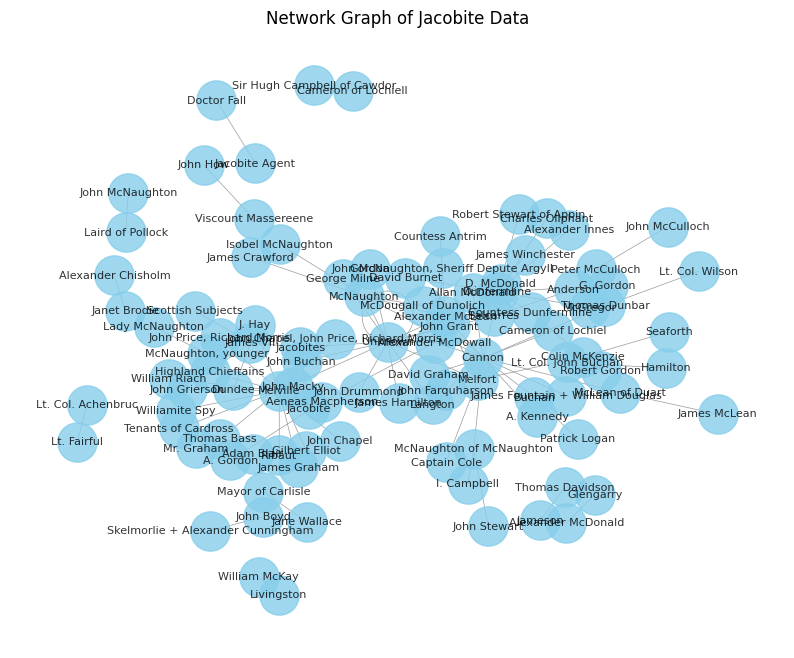

In [6]:
plt.figure(figsize=(10, 8))
nx.draw_networkx(
G,
    pos=nx.spring_layout(G, k=0.15, iterations=20), # Positions for all nodes
    with_labels=True,
    node_color='skyblue',
    node_size=800,
    edge_color='gray',
    font_size=8,
    width=0.5,
    alpha=0.8
)
plt.title('Network Graph of Jacobite Data')
plt.axis('off') # Turn off the axis
plt.show()

In [7]:
new_network_data = pd.read_csv('/content/Jacobite_sheets - New-sheet.csv')
print("New network data loaded successfully.")
new_network_data.head()

New network data loaded successfully.


,From Type,From Name,Edge Type,To Type,To Name,Weight
0,Person,Unknown,Letter,Person,Dunfermline,3
1,Person,Robert Gordon,Letter,Person,Countess Dunfermline,1
2,Person,Alexander Innes,Letter,Person,Dunfermline,1
3,Person,David Burnet,Letter,Person,Dunfermline,1
4,Person,G. Gordon,Letter,Person,Dunfermline,1


In [8]:
print("First 5 rows of the new_network_data DataFrame:")
print(new_network_data.head())

print("\nInformation about the new_network_data DataFrame:")
new_network_data.info()

print("\nDescriptive statistics for the new_network_data DataFrame:")
print(new_network_data.describe())

First 5 rows of the new_network_data DataFrame:
  From Type        From Name Edge Type To Type               To Name  Weight
0    Person          Unknown    Letter  Person           Dunfermline       3
1    Person    Robert Gordon    Letter  Person  Countess Dunfermline       1
2    Person  Alexander Innes    Letter  Person           Dunfermline       1
3    Person     David Burnet    Letter  Person           Dunfermline       1
4    Person        G. Gordon    Letter  Person           Dunfermline       1

Information about the new_network_data DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   From Type  98 non-null     object
 1   From Name  98 non-null     object
 2   Edge Type  98 non-null     object
 3   To Type    98 non-null     object
 4   To Name    98 non-null     object
 5   Weight     98 non-null     int64 
dtypes: int64(1), object(

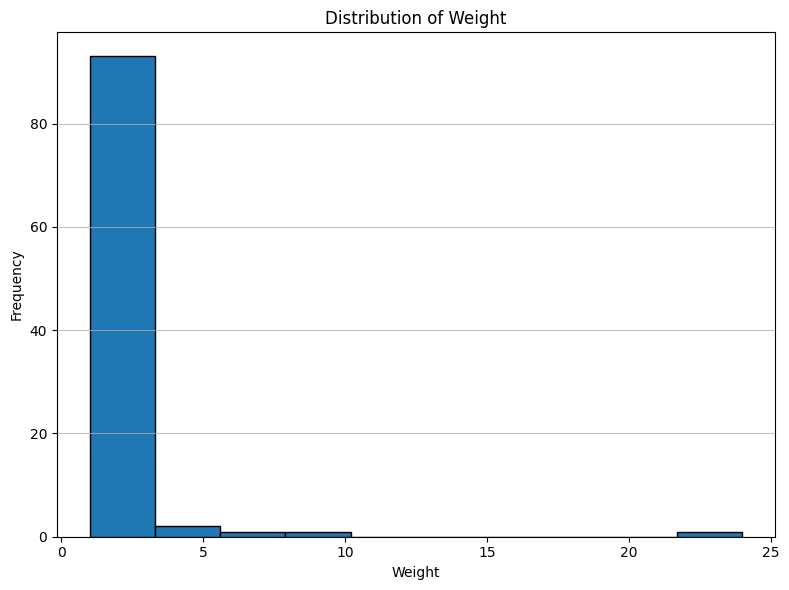

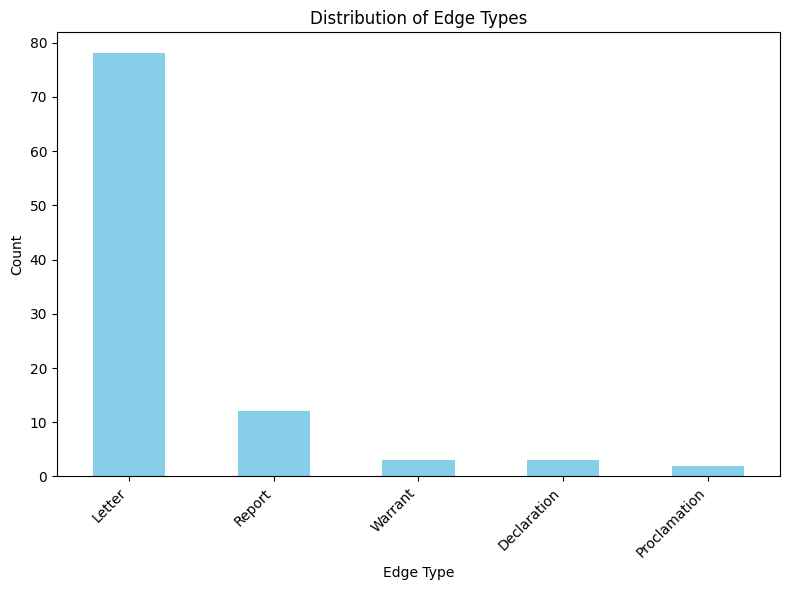

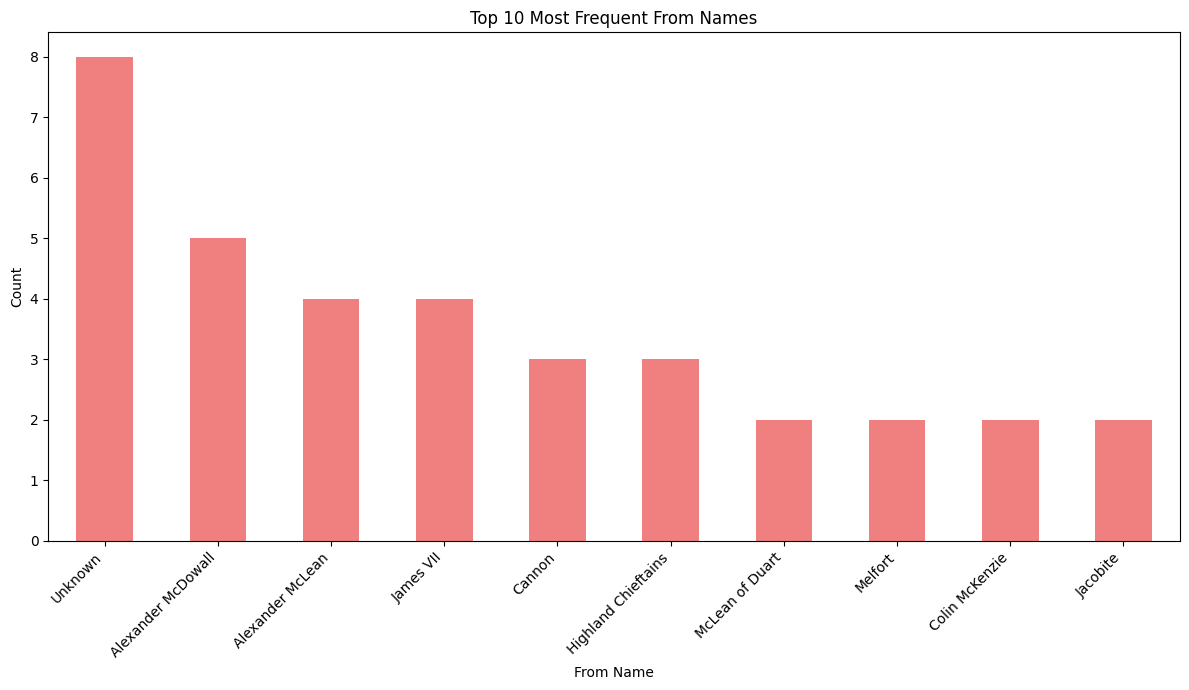

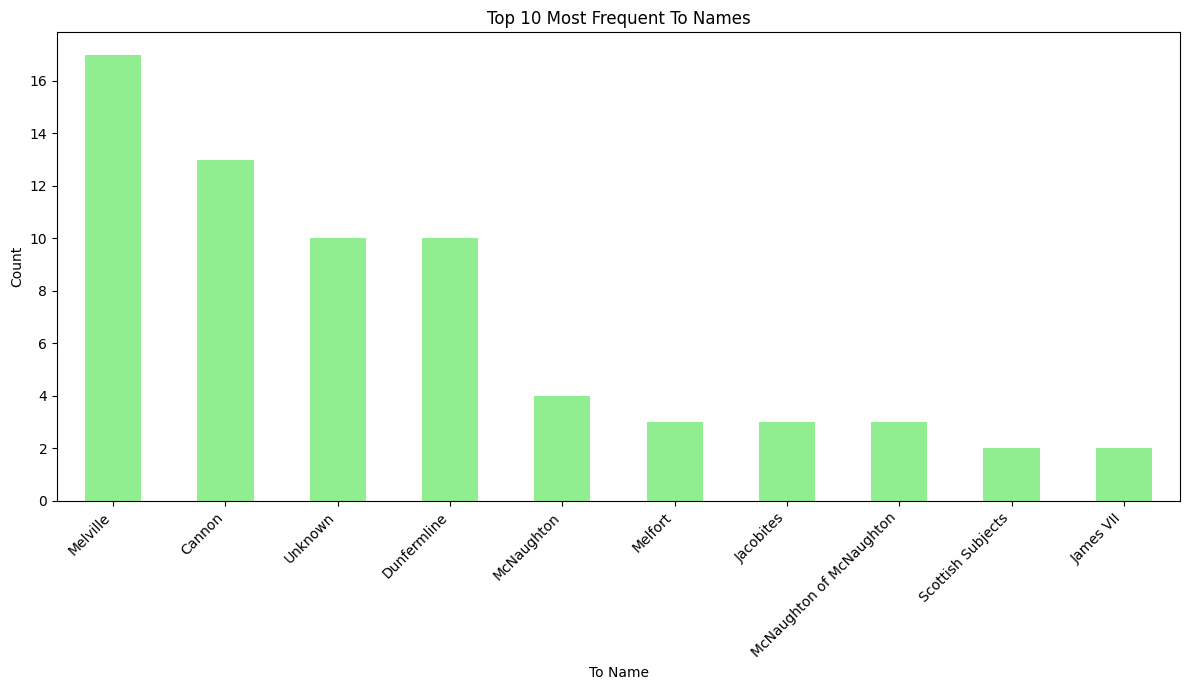

In [9]:
plt.figure(figsize=(8, 6))
new_network_data['Weight'].plot(kind='hist', bins=10, edgecolor='black')
plt.title('Distribution of Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
new_network_data['Edge Type'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Edge Types')
plt.xlabel('Edge Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
top_10_from_name = new_network_data['From Name'].value_counts().head(10)
top_10_from_name.plot(kind='bar', color='lightcoral')
plt.title('Top 10 Most Frequent From Names')
plt.xlabel('From Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
top_10_to_name = new_network_data['To Name'].value_counts().head(10)
top_10_to_name.plot(kind='bar', color='lightgreen')
plt.title('Top 10 Most Frequent To Names')
plt.xlabel('To Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
correspondence_df = pd.read_csv('/content/Networking-sheets-originals - Jacobite Papers Edges.csv')
print("Successfully loaded /content/Networking-sheets-originals - Jacobite Papers Edges.csv into correspondence_df.")
print("First 5 rows of correspondence_df:")
correspondence_df.head()

Successfully loaded /content/Networking-sheets-originals - Jacobite Papers Edges.csv into correspondence_df.
First 5 rows of correspondence_df:


,From Type,From Name,Edge Type,To Type,To Name,Date,Weight,NRS Reference
0,Person,Unknown,WROTE LETTER TO,Person,Dunfermline,"1689, Jan 20",1,GD26/8/1
1,Person,Robert Gordon,WROTE LETTER TO,Person,Countess Dunfermline,"1689, Feb 2",1,GD26/8/2
2,Person,Alexander Innes,WROTE LETTER TO,Person,Dunfermline,"1689, Feb 14",1,GD26/8/3
3,Person,David Burnet,WROTE LETTER TO,Person,Dunfermline,"1689, Feb 19",1,GD26/8/4
4,Person,G. Gordon,WROTE LETTER TO,Person,Dunfermline,"1689, Mar 23",1,GD26/8/5


In [30]:
correspondence_df_indexed['Month'] = correspondence_df_indexed['Date'].dt.month
print("Month column extracted successfully:")
print(correspondence_df_indexed.head())

Month column extracted successfully:
        Date  Correspondence_Count  year  dayofweek  week  Month
0 1689-01-20                     1  1689          3     3      1
1 1689-01-21                     0  1689          4     3      1
2 1689-01-22                     0  1689          5     3      1
3 1689-01-23                     0  1689          6     3      1
4 1689-01-24                     0  1689          0     4      1


In [32]:
monthly_correspondence_heatmap_data = correspondence_df_indexed.groupby(['year', 'Month'])['Correspondence_Count'].sum().unstack(fill_value=0)

print("First 5 rows of monthly_correspondence_heatmap_data:")
print(monthly_correspondence_heatmap_data.head())

First 5 rows of monthly_correspondence_heatmap_data:
Month  1   2   3   4   5   6   7   8   9   10  11  12
year                                                 
1689    1   3   2   6   5   3   5  12   6   9   4   9
1690    4   4   4   2   1   2   1   1   2   0   0   2
1691    1   0   0   1   0   0   0   2   0   0   0   0
1692    1   0   0   0   0   0   0   0   0   0   0   0


In [34]:
import calendar

month_names = [calendar.month_abbr[i] for i in range(1, 13)]
print(f"Generated month abbreviations: {month_names}")

Generated month abbreviations: ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


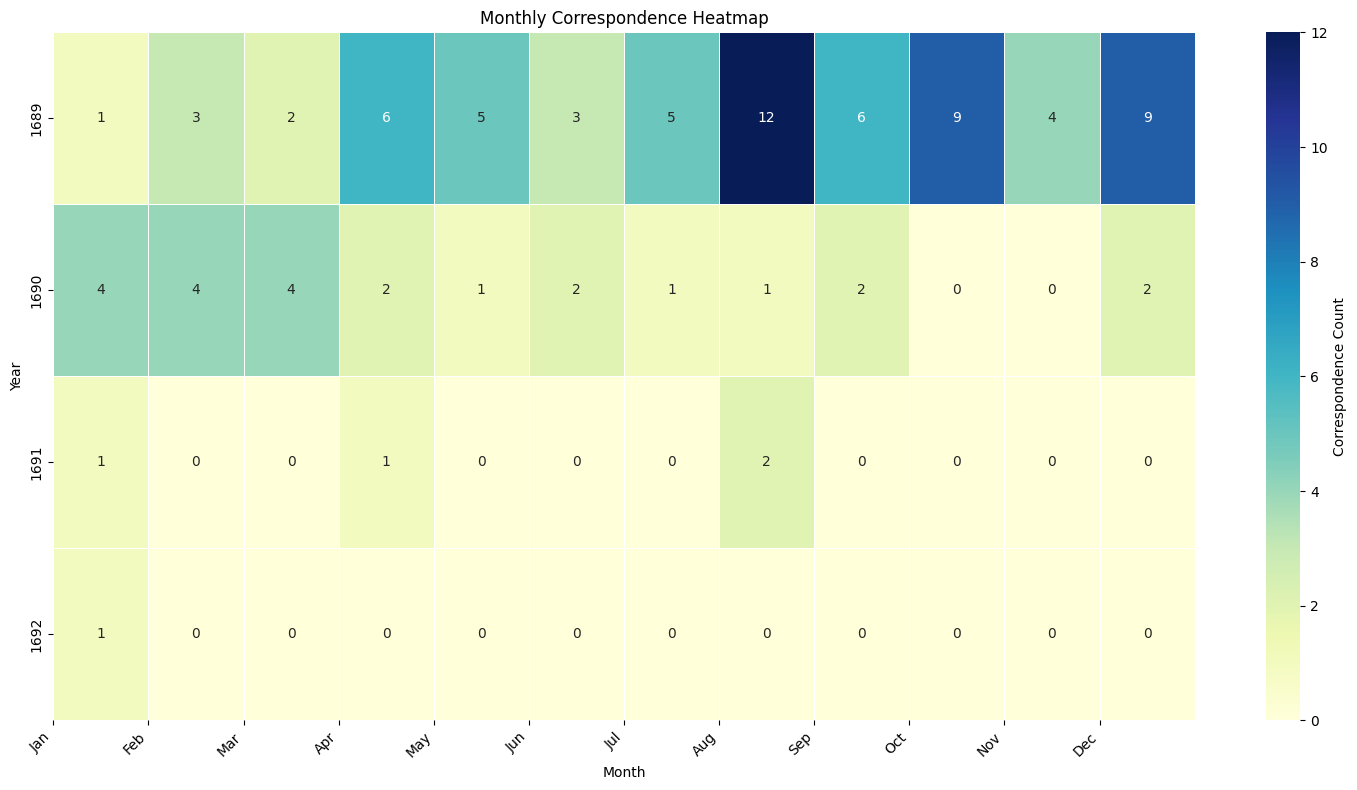

Monthly correspondence heatmap generated and displayed.


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
sns.heatmap(
    monthly_correspondence_heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt='d',
    linewidths=.5,
    cbar_kws={'label': 'Correspondence Count'}
)
plt.title('Monthly Correspondence Heatmap')
plt.xlabel('Month')
plt.ylabel('Year')
plt.xticks(ticks=range(len(month_names)), labels=month_names, rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Monthly correspondence heatmap generated and displayed.")

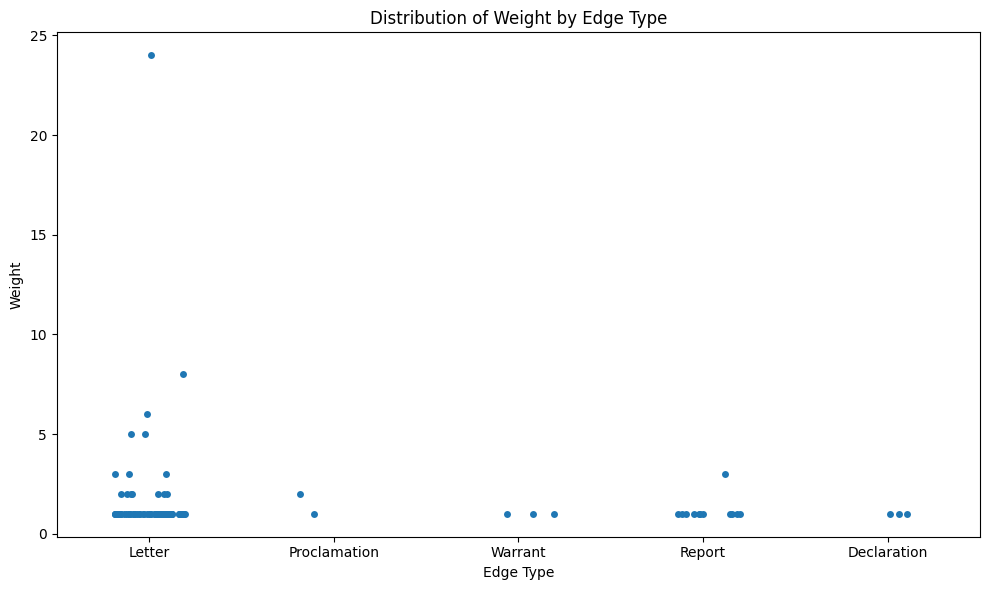

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.stripplot(x='Edge Type', y='Weight', data=new_network_data, jitter=0.2) # Added jitter for better spread
plt.title('Distribution of Weight by Edge Type')
plt.xlabel('Edge Type')
plt.ylabel('Weight')
plt.tight_layout()
plt.show()